****
**1. Install Required Libraries**
****

In [1]:
!pip install tensorflow matplotlib scikit-learn


****
**2. Mount Google Drive**
****

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


****
**3. Define Dataset Paths**
****

In [3]:
TRAIN_DIR = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/train'
TEST_DIR  = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/test'
VAL_DIR   = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/val'

****
**4. Verify Dataset Structure**
****

In [4]:
import os
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(TEST_DIR))
print(os.listdir(TRAIN_DIR))

True
True
['NORMAL', 'PNEUMONIA']


****
**5. Create a Sample Dataset of 50 Images**
****

In [5]:
import os
import shutil
import random

SOURCE_TRAIN = "/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/train"
TARGET = "/content/sample_dataset"

# Create folders
os.makedirs(f"{TARGET}/NORMAL", exist_ok=True)
os.makedirs(f"{TARGET}/PNEUMONIA", exist_ok=True)

# Select 25 images from each class
for cls in ["NORMAL", "PNEUMONIA"]:
    source_folder = os.path.join(SOURCE_TRAIN, cls)
    images = [img for img in os.listdir(source_folder)
              if img.lower().endswith(('.jpeg', '.jpg', '.png'))]
    selected = random.sample(images, 25)
    for img in selected:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(TARGET, cls, img)
        )
print("50-image dataset created successfully.")

50-image dataset created successfully.


****
**6. Verify Sample Dataset**
****


In [6]:
import os

print("NORMAL:", len(os.listdir("/content/sample_dataset/NORMAL")))
print("PNEUMONIA:", len(os.listdir("/content/sample_dataset/PNEUMONIA")))

NORMAL: 25
PNEUMONIA: 25


****
**7. Load Dataset**
****


In [7]:
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 8

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/sample_dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/sample_dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 50 files belonging to 2 classes.
Using 40 files for training.
Found 50 files belonging to 2 classes.
Using 10 files for validation.


****
**Check Dataset Size**
****

In [8]:
print("Training batches:", len(train_ds))
print("Testing batches:", len(test_ds))

Training batches: 5
Testing batches: 2


****
**9. ResNet50 **
****


In [9]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

****
**10. Compile Model**
****


In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("ResNet50 compiled successfully")

ResNet50 compiled successfully


****
**11. Train Model**
****


In [11]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.3750 - loss: 0.7149 - val_accuracy: 0.4000 - val_loss: 0.7134
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5250 - loss: 0.7120 - val_accuracy: 0.4000 - val_loss: 0.7418
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5250 - loss: 0.7026 - val_accuracy: 0.4000 - val_loss: 0.7191
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4750 - loss: 0.6995 - val_accuracy: 0.6000 - val_loss: 0.6909
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4500 - loss: 0.6963 - val_accuracy: 0.6000 - val_loss: 0.6832


****
**12. Evaluate Model**
****


In [12]:
loss, accuracy = model.evaluate(test_ds)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - accuracy: 0.6000 - loss: 0.6832
Test Loss: 0.6832002401351929
Test Accuracy: 0.6000000238418579


****
**13. Accuracy Graph**
****


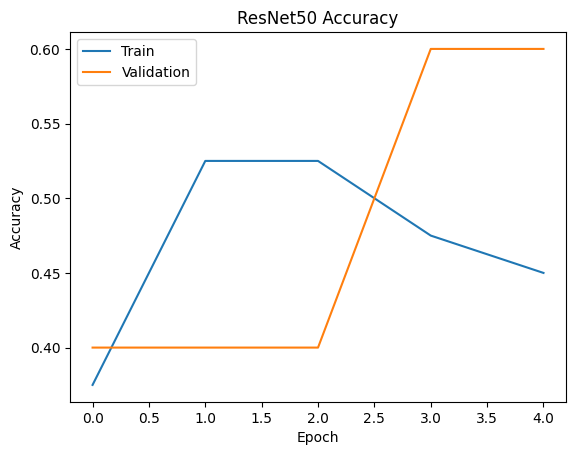

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

****
**14. Loss Graph**
****

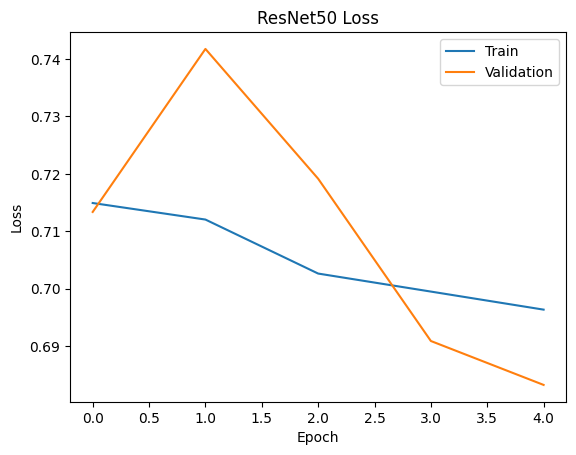

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

****
**15. Save the Model**
****

In [15]:
model.save('resnet50_pneumonia_model.h5')